In [24]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import FancyBboxPatch
from sklearn.neighbors import NearestNeighbors
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from scipy.stats import pearsonr, spearmanr


In [25]:
BASE_DIR   = Path("/Users/bgadmin/Downloads/multiomics_preproc")
OUT_DIR    = BASE_DIR / "knn_index"

MOFA_FACTORS_PATH = BASE_DIR / "mofa_factors.parquet"
META_PATH         = BASE_DIR / "meta_final.tsv"

# Identifier and label columns
ID_COL        = "biosample_id"
LABEL_COL     = "cancer_group"

# Parameters kNN
K       = 50
METRIC  = "euclidean"
N_FACTORS_FOR_KNN = 20   

OUT_DIR.mkdir(parents=True, exist_ok=True)

### Load the feature space

In [26]:
# MOFA factors (latent space)
Z_mofa_df = pd.read_parquet(MOFA_FACTORS_PATH)
Z_mofa_df.index = Z_mofa_df.index.astype(str)
print(f"Load MOFA factors  : {Z_mofa_df.shape[0]:,} samples x {Z_mofa_df.shape[1]} factors")

# Aligned metadata 
meta = pd.read_csv(META_PATH, sep="\t", dtype=str)
meta[ID_COL] = meta[ID_COL].astype(str)
print(f"Load metadata    : {meta.shape[0]:,} samples x {meta.shape[1]} columns")

#  Verefication of the alignment 
assert list(Z_mofa_df.index) == list(meta[ID_COL]), \
    "ERRoR : Z_mofa_df and meta are not align"

print(f"\nAlignment OK — {len(Z_mofa_df):,} commons samples")
print(f"\nDistribution cancer_group :")
print(meta[LABEL_COL].value_counts().head(10).to_string())
print(f"\n  ... {meta[LABEL_COL].nunique()} unique groups in total")

Load MOFA factors  : 9,592 samples x 20 factors
Load metadata    : 9,592 samples x 10184 columns

Alignment OK — 9,592 commons samples

Distribution cancer_group :
cancer_group
Lung (C30-C39)                 1302
Gynecologic (C51-C58)          1135
Urinary (C64-C68)              1110
Breast (C50)                    969
Brain (C71)                     737
Thyroid/Endocrine (C73-C75)     719
Male genital (C60-C63)          617
Colorectal (C18-C20)            565
C16                             406
Liver/Biliary (C22-C24)         398

  ... 22 unique groups in total


### Build kNN

In [27]:
factor_cols = Z_mofa_df.columns[:N_FACTORS_FOR_KNN].tolist()

ids = Z_mofa_df.index.astype(str).to_numpy()
X   = Z_mofa_df[factor_cols].to_numpy(dtype=np.float32)

n = X.shape[0]

if n < (K + 1):
    raise ValueError(f"n={n} < K+1={K+1} — not enough samples for kNN")

print(f"\nBuilding kNN on {n:,} samples x {len(factor_cols)} MOFA factors")
print(f"Parameters : K={K}, metric={METRIC}\n")

# Fit
nn = NearestNeighbors(n_neighbors=K + 1, metric=METRIC, algorithm="auto")
nn.fit(X)
dists, idx = nn.kneighbors(X, return_distance=True)

# Drop self wherever it appears
rows = np.arange(n)[:, None]
mask = idx != rows

idx2   = np.empty((n, K), dtype=np.int32)
dist2  = np.empty((n, K), dtype=np.float32)

for i in range(n):
    ii      = idx[i][mask[i]]
    dd      = dists[i][mask[i]]
    idx2[i] = ii[:K]
    dist2[i] = dd[:K]

idx   = idx2
dists = dist2

# Map neighbor indices → neighbor biosample_ids
neigh_ids = ids[idx]

# ── Sauvegarde ────────────────────────────────────────────────────
out_idx  = OUT_DIR / f"mofa_knn_idx_k{K}_factors{len(factor_cols)}_{METRIC}.parquet"
out_dist = OUT_DIR / f"mofa_knn_dist_k{K}_factors{len(factor_cols)}_{METRIC}.parquet"

df_idx = pd.DataFrame(neigh_ids, columns=[f"nn{i+1}" for i in range(K)])
df_idx.insert(0, ID_COL, ids)

df_dist = pd.DataFrame(dists, columns=[f"d{i+1}" for i in range(K)])
df_dist.insert(0, ID_COL, ids)

df_idx.to_parquet(out_idx,   index=False)
df_dist.to_parquet(out_dist, index=False)

# Manifest 
knn_manifest = [{
    "space":          "MOFA_multiomics",
    "n_samples":      int(n),
    "k":              int(K),
    "metric":         METRIC,
    "n_factors_used": int(len(factor_cols)),
    "factors_used":   ",".join(factor_cols),
    "knn_idx_file":   out_idx.name,
    "knn_dist_file":  out_dist.name,
}]

manifest_path = OUT_DIR / "knn_manifest.tsv"
pd.DataFrame(knn_manifest).to_csv(manifest_path, sep="\t", index=False)

print(f"[saved] {out_idx.name}")
print(f"[saved] {out_dist.name}")
print(f"[saved] knn manifest → {manifest_path}")

# Stats de distance
flat_dists = dists.ravel()
print(f"\nDistance stats (all {n*K:,} neighbor pairs) :")
print(f"  min    : {flat_dists.min():.4f}")
print(f"  median : {np.median(flat_dists):.4f}")
print(f"  p90    : {np.percentile(flat_dists, 90):.4f}")
print(f"  max    : {flat_dists.max():.4f}")


Building kNN on 9,592 samples x 20 MOFA factors
Parameters : K=50, metric=euclidean

[saved] mofa_knn_idx_k50_factors20_euclidean.parquet
[saved] mofa_knn_dist_k50_factors20_euclidean.parquet
[saved] knn manifest → /Users/bgadmin/Downloads/multiomics_preproc/knn_index/knn_manifest.tsv

Distance stats (all 479,600 neighbor pairs) :
  min    : 0.5586
  median : 4.5048
  p90    : 6.4714
  max    : 33.2222


In [28]:
# Building kNN cosine

nn_cos = NearestNeighbors(n_neighbors=K + 1, metric="cosine", algorithm="auto")
nn_cos.fit(X)
dists_cos, idx_cos = nn_cos.kneighbors(X, return_distance=True)

# Drop self wherever it appears
rows = np.arange(n)[:, None]
mask_cos = idx_cos != rows

idx2_cos   = np.empty((n, K), dtype=np.int32)
dist2_cos  = np.empty((n, K), dtype=np.float32)

for i in range(n):
    ii            = idx_cos[i][mask_cos[i]]
    dd            = dists_cos[i][mask_cos[i]]
    idx2_cos[i]   = ii[:K]
    dist2_cos[i]  = dd[:K]

neigh_ids_cos   = ids[idx2_cos]    # (n, K) biosample_ids neighbors cosine
neigh_dists_cos = dist2_cos        # (n, K) distances cosine

# Save kNN cosine
out_idx_cos  = OUT_DIR / f"mofa_knn_idx_k{K}_factors{N_FACTORS_FOR_KNN}_cosine.parquet"
out_dist_cos = OUT_DIR / f"mofa_knn_dist_k{K}_factors{N_FACTORS_FOR_KNN}_cosine.parquet"

df_idx_cos = pd.DataFrame(neigh_ids_cos, columns=[f"nn{i+1}" for i in range(K)])
df_idx_cos.insert(0, ID_COL, ids)

df_dist_cos = pd.DataFrame(neigh_dists_cos, columns=[f"d{i+1}" for i in range(K)])
df_dist_cos.insert(0, ID_COL, ids)

df_idx_cos.to_parquet(out_idx_cos,   index=False)
df_dist_cos.to_parquet(out_dist_cos, index=False)

print(f"[saved] {out_idx_cos.name}")
print(f"[saved] {out_dist_cos.name}")

# Stats de distance cosine
flat_cos = neigh_dists_cos.ravel()
print(f"\nDistance stats cosine :")
print(f"  min    : {flat_cos.min():.4f}")
print(f"  median : {np.median(flat_cos):.4f}")
print(f"  p90    : {np.percentile(flat_cos, 90):.4f}")
print(f"  max    : {flat_cos.max():.4f}")

[saved] mofa_knn_idx_k50_factors20_cosine.parquet
[saved] mofa_knn_dist_k50_factors20_cosine.parquet

Distance stats cosine :
  min    : 0.0010
  median : 0.1786
  p90    : 0.3039
  max    : 0.6639



Jaccard overlap (euclidean vs cosine) :
  mean   : 0.684
  median : 0.695
  std    : 0.174
  min    : 0.010
  max    : 1.000


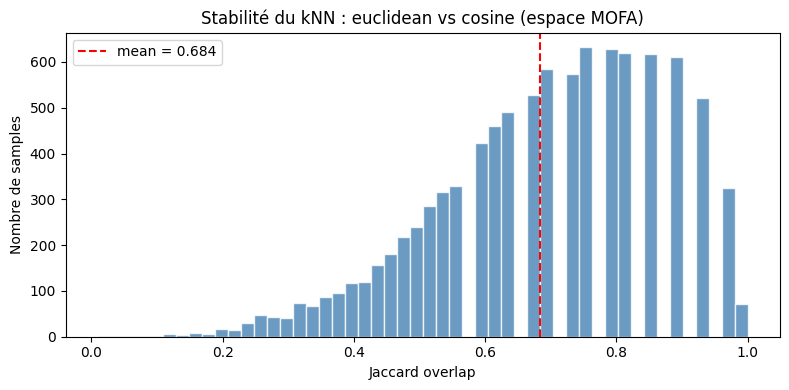

In [29]:
# Jaccard overlap euclidean vs cosine 
jaccard_scores = np.empty(n, dtype=np.float32)

for i in range(n):
    set_euc = set(neigh_ids[i].astype(str))      # neighbors euclidean
    set_cos = set(neigh_ids_cos[i].astype(str))  # neigbors cosine

    intersection = len(set_euc & set_cos)
    union        = len(set_euc | set_cos)

    # Union cannot be 0 because K > 0
    jaccard_scores[i] = intersection / union

print(f"\nJaccard overlap (euclidean vs cosine) :")
print(f"  mean   : {jaccard_scores.mean():.3f}")
print(f"  median : {np.median(jaccard_scores):.3f}")
print(f"  std    : {jaccard_scores.std():.3f}")
print(f"  min    : {jaccard_scores.min():.3f}")
print(f"  max    : {jaccard_scores.max():.3f}")

# Distribution du Jaccard
plt.figure(figsize=(8, 4))
plt.hist(jaccard_scores, bins=50, color="steelblue", alpha=0.8, edgecolor="white")
plt.axvline(jaccard_scores.mean(), color="red", linestyle="--",
            label=f"mean = {jaccard_scores.mean():.3f}")
plt.xlabel("Jaccard overlap")
plt.ylabel("Nombre de samples")
plt.title("Stabilité du kNN : euclidean vs cosine (espace MOFA)")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# Load of kNN index saved

idx_path  = OUT_DIR / f"mofa_knn_idx_k{K}_factors{N_FACTORS_FOR_KNN}_{METRIC}.parquet"
dist_path = OUT_DIR / f"mofa_knn_dist_k{K}_factors{N_FACTORS_FOR_KNN}_{METRIC}.parquet"

ids_df  = pd.read_parquet(idx_path)   # table : biosample_id + nn1..nn50
dist_df = pd.read_parquet(dist_path)  # table : biosample_id + d1..d50

# Extract the IDs table in the filer order 
ids = ids_df[ID_COL].astype(str).to_numpy()  # shape (9592,)

# Align metadata in this order
# set_index + reindex ensures that each line in meta_aligned
# corresponds exactly to the same line in ids_df and dist_df
meta_aligned = (
    meta
    .set_index(ID_COL)   # biosample_id become l'index
    .reindex(ids)        # reorganize in the same order as the ids 
    .reset_index()       # put biosample_id in column
)

# Verification : no metadata should missed after the algnment 
n_missing = meta_aligned.isna().all(axis=1).sum()
if n_missing > 0:
    raise ValueError(f"{n_missing} samples without metadata after the aligment")

# Extract the NumPy matrices of neighbors and distances
# Remove the biosample_id column to keep only nn1..nn50
nn_cols   = [c for c in ids_df.columns  if c != ID_COL]
dist_cols = [c for c in dist_df.columns if c != ID_COL]

knn_ids   = ids_df[nn_cols].to_numpy(dtype=object)    # shape (9592, 50)
knn_dists = dist_df[dist_cols].to_numpy(dtype=np.float32)  # shape (9592, 50)

print(f"Index load :")
print(f"  samples   : {len(ids):,}")
print(f"  K neighbors : {knn_ids.shape[1]}")
print(f"  metric  : {METRIC}")

Index load :
  samples   : 9,592
  K neighbors : 50
  metric  : euclidean


In [31]:
# Final decision 
# calcule of the purity (topography only) for the 2 metrics

def quick_topography_purity(neigh_id_matrix, k=25):
    """
    Calculates the purity topography (cancer_group) quickly
    for all samples without calling retrieve_by_id.
    
    """
    # Retrieve the cancer_group of each sample in order of ids
    labels = meta_aligned[LABEL_COL].to_numpy()

    # Build a biosample_id → index mapping to retrieve the labels
    id_to_idx = {bid: i for i, bid in enumerate(ids)}

    purities = np.empty(n, dtype=np.float32)

    for i in range(n):
        query_label = labels[i]

        # Retrieve the labels of the first k neighbors
        neighbor_labels = []
        for nid in neigh_id_matrix[i, :k].astype(str):
            ni = id_to_idx.get(nid)
            if ni is not None:
                neighbor_labels.append(labels[ni])

        if len(neighbor_labels) == 0:
            purities[i] = 0.0
            continue

        # Purity = fraction of neighbors with the same cancer_group
        n_same     = sum(1 for l in neighbor_labels if l == query_label)
        purities[i] = n_same / len(neighbor_labels)

    return purities

# Calculate the purity for both metrics.
purity_euc = quick_topography_purity(neigh_ids,     k=25)
purity_cos = quick_topography_purity(neigh_ids_cos, k=25)

print(f"Purity topography (K=25) :")
print(f"  euclidean : mean={purity_euc.mean():.3f}  median={np.median(purity_euc):.3f}")
print(f"  cosine    : mean={purity_cos.mean():.3f}  median={np.median(purity_cos):.3f}")

# Automatic selection based on purity
if purity_euc.mean() >= purity_cos.mean():
    BEST_METRIC  = "euclidean"
    neigh_ids_best   = neigh_ids
    neigh_dists_best = dists
    print(f"\n→ Metric choose : euclidean (purity={purity_euc.mean():.3f})")
else:
    BEST_METRIC  = "cosine"
    neigh_ids_best   = neigh_ids_cos
    neigh_dists_best = neigh_dists_cos
    print(f"\n→ Metric choose : cosine (purity={purity_cos.mean():.3f})")

print(f"  Jaccard average overlap between the two: {jaccard_scores.mean():.3f}")

Purity topography (K=25) :
  euclidean : mean=0.656  median=0.720
  cosine    : mean=0.658  median=0.720

→ Metric choose : cosine (purity=0.658)
  Jaccard average overlap between the two: 0.684


### 3. Retrieval Function Specification (Neighbors + Distances + Metadata)

The retrieval engine is designed to return a comprehensive Python `dict` containing four structured blocks. This function acts as the core clinical decision support tool by contextualizing a query sample within its multi-omic neighborhood.

#### A. Structured Output Architecture

The function returns a `dict` with the following keys:

* **`query` block**: Metadata detailing the input sample and the parameters of the run.
    * `analysis_id`: The identifier of the sample (if it belongs to the existing dataset).
    * `icdot_root`: The primary ICD-O Topography root (either provided as input or inferred).
    * `k`: The number of nearest neighbors requested.
    * `space`: Description of the similarity space and the underlying representation used (e.g., Stage 2A Latent MOFA vs. Stage 2B SNF Network).
    * `distance_metric`: The metric used to compute proximity (e.g., Euclidean, Cosine, Precomputed Network Distance).
* **`neighbors` table**: A `pd.DataFrame` where each row corresponds to a retrieved neighbor, sorted by proximity, containing:
    * `ranking`: Sequential rank from $1$ to $k$.
    * `analysis_id`: Unique identifier of the neighboring sample.
    * `distance`: Numerical distance to the query sample.
    * `icdo_morphology_id`: Histological classification.
    * `icdo_topography_id`: Specific anatomical site subcode.
    * `resolution_categories`: Technical profiling resolution class.
    * `source_group`: Cohort or institution of origin.
* **`summary` block**: An aggregated overview computed directly from the neighbors' table:
    * `label_hist`: DataFrames showing absolute counts and relative fractions for both morphology codes and topology subsites.
    * `platform_mix`: Counts and fractions of the data platform resolutions represented in the neighborhood.
    * `source_mix`: Counts and fractions of the participating `source_group` cohorts.
    * `distance_summary`: Descriptive statistics of the neighborhood radius ($\text{Min}$, $\text{Median}$, $\text{Max}$).
* **`key_cnv_events` block**: A summary of the most frequent or highly weighted Copy Number Variation (CNV) alterations (e.g., specific focal amplifications or deletions) observed across the retrieved neighbors.


#### B. Execution Logic for Unseen Samples (New Patients)

When evaluating a completely new profile that is not part of the reference index:

1.  **Explicit Root Input (Required)**: The user must provide the primary anatomical site (`icdot_roots`) as a prior constraint to narrow down or validate the molecular search space.
2.  **Inference Fallback (Future Phase)**: If the `icdot_root` is missing or unknown for the new sample, a separate predictive machine learning model will need to be executed first to infer the most likely tissue of origin based on the multi-omic profile before entering the retrieval index. *Note: This inference model is treated as a low-priority implementation step and will be addressed last.*

In [32]:
# ── Utility Function: Summarizing a Categorical Column ───────
# For a series like ["Breast", "Breast", "Lung", "Breast"]
# Returns a DataFrame with the counts and fractions of each value
# Example output:

# cancer_group count frac
# Breast 3 0.75
# Lung 1 0.25

def counts_and_fracs(series):
    value_counts = series.value_counts(dropna=False)
    result = pd.DataFrame({
        "count": value_counts,
        "frac":  (value_counts / value_counts.sum()).round(4)
    })
    result.index.name = series.name
    return result.reset_index()

In [33]:
def retrieve_by_id(query_id, k=25):
    '''
    Given a biosample_id, this function:
        1. Finds its position in the index
        2. Retrieves its k pre-calculated neighbors and their distances
        3. Joins the biological metadata of these neighbors
        4. Calculates the purity (fraction of neighbors with the same type of cancer)
        5. Returns a dictionary with all this organized into 4 blocks
    '''

    query_id = str(query_id)

    # Locate the query in the index
    # np.where returns the positions where the condition is true

    positions = np.where(ids == query_id)[0]

    if len(positions) == 0:
        raise KeyError(f"biosample_id non trouvé dans l'index : {query_id}")

    i = int(positions[0])  # index of hte lign in the matrix 

    #Retrieve the k neighbors and their distances
    # knn_ids[i] contains the 50 biosample_ids of the neighbors of sample i
    # knn_dists[i] contains the 50 corresponding distances
    
    neigh_ids   = knn_ids[i,   :k].astype(str)
    neigh_dists = knn_dists[i, :k].astype(float)

    # Safety: remove the self-service area if it appears among the neighbors
    not_self    = neigh_ids != query_id
    neigh_ids   = neigh_ids[not_self][:k]
    neigh_dists = neigh_dists[not_self][:k]

    # build the neighbors table with their metadata
    df_neighbors = pd.DataFrame({
        "rank":         np.arange(1, len(neigh_ids) + 1, dtype=int),
        "biosample_id": neigh_ids,
        "distance":     neigh_dists,
    })

    # Créer un dictionnaire biosample_id → métadonnées pour la jointure
    # On sélectionne les colonnes biologiques utiles
    cols_meta = [c for c in [LABEL_COL, "source_group", "icdo_topography_id"]
                 if c in meta_aligned.columns]

    meta_map = meta_aligned.set_index(ID_COL)[cols_meta]

    # Jointure : pour chaque voisin, on récupère son cancer_group etc.
    df_neighbors = df_neighbors.join(meta_map, on="biosample_id")


    # Calculate the purity
    # Purity = 1.0 → all neighbors have the same cancer_group → perfect
    # Purity = 0.0 → no neighbors have the same cancer_group → bad

    # Retreive  cancer_group of th query
    query_label_rows = meta_aligned.loc[
        meta_aligned[ID_COL] == query_id, LABEL_COL
    ].values

    if len(query_label_rows) > 0 and LABEL_COL in df_neighbors.columns:
        query_label = query_label_rows[0]
        # Count how many neigbors have the same cancer_group
        n_same  = (df_neighbors[LABEL_COL] == query_label).sum()
        purity  = float(n_same / len(df_neighbors))
    else:
        query_label = None
        purity      = None

    # Assemble the results into 4 blocks
    # query → what was searched for and in which space
    # neighbors → the complete neighbors table with metadata
    # summary → distribution of cancer_groups + distance stats
    # purity → the biological validation score
    result = {
        "query": {
            "biosample_id": query_id,
            "cancer_group": query_label,
            "k":            int(len(neigh_ids)),
            "space":        "MOFA_multiomics",
            "metric":       METRIC,
        },
        "neighbors": df_neighbors,
        "summary": {
            "cancer_group_dist": counts_and_fracs(df_neighbors[LABEL_COL])
                                 if LABEL_COL in df_neighbors.columns else None,
            "distance_stats": {
                "min":    float(np.min(neigh_dists)),
                "median": float(np.median(neigh_dists)),
                "max":    float(np.max(neigh_dists)),
            }
        },
        "purity": purity,
    }

    return result

In [34]:
example_id = ids[0]
result     = retrieve_by_id(example_id, k=25)

print(f"Query         : {result['query']['biosample_id']}")
print(f"Cancer group  : {result['query']['cancer_group']}")
print(f"Purity top-25 : {result['purity']:.3f}")
print(f"\nTop 10 voisins :")
print(result["neighbors"].head(10).to_string(index=False))
print(f"\nDistribution cancer_group parmi les 25 voisins :")

Query         : pgxbs-kftvho6e
Cancer group  : Esophagus/Intestine (C15-C17-C21-C26)
Purity top-25 : 0.120

Top 10 voisins :
 rank   biosample_id  distance                          cancer_group icdo_topography_id
    1 pgxbs-kftvhywn  2.469050                        Lung (C30-C39)    pgx:icdot-C32.9
    2 pgxbs-kftvi01i  3.321030 Esophagus/Intestine (C15-C17-C21-C26)    pgx:icdot-C15.4
    3 pgxbs-kftvi4x4  3.519266 Esophagus/Intestine (C15-C17-C21-C26)    pgx:icdot-C15.4
    4 pgxbs-kftvht1s  3.628786                        Lung (C30-C39)    pgx:icdot-C34.3
    5 pgxbs-kftvhirt  4.053164                 Head & Neck (C00_C14)    pgx:icdot-C06.0
    6 pgxbs-kftvhmts  4.114317                        Lung (C30-C39)    pgx:icdot-C34.3
    7 pgxbs-kftvhrc7  4.209785                        Lung (C30-C39)    pgx:icdot-C34.1
    8 pgxbs-kftvhpu9  4.228464                 Head & Neck (C00_C14)    pgx:icdot-C02.9
    9 pgxbs-kftvhned  4.251744                        Lung (C30-C39)    pgx:icdot-C

### QC :
- check if the sample is not a self-neighbors
- check if the distances are not monotone (distance neighbor 1 <= neighbor 2 <= ... <= neighbor K)
- chekc if the IDS are right and exist 

In [35]:
n = len(ids)

# no self-neighbor
# Construction of a table with the IDs of each sample and then we look if the IDs is in in its own neighbors 
ids_col = ids.reshape(-1, 1)          # (n, 1) — each sample one time
# knn_ids is (n, K) — comparision of each ID with its lign of neigbors
self_present = np.any(knn_ids == ids_col, axis=1)  # (n,) booleen
n_self = int(self_present.sum())

print(f"\nSelf-neighbor check")
print(f"    Samples with self in neighbors : {n_self} / {n}")
if n_self == 0:
    print(f"    OK — no self-neighbor found")
else:
    print(f"    WARNING — {n_self} samples have themselves as neighbor")
    bad_ids = ids[self_present][:5]
    print(f"    First 5 cases : {bad_ids}")

# Monotonic distances
# For each sample, the distances must be increasing

# np.diff calculates consecutive differences: d[1]-d[0], d[2]-d[1], ...
# If all differences are >= 0, the distances are monotonic
diffs = np.diff(knn_dists, axis=1)           # shape (n, K-1)
n_non_monotone = int((diffs < -1e-5).any(axis=1).sum())  # tolérance numérique

print(f"\nMonotone distances check")
print(f"    Samples with non-monotone distances : {n_non_monotone} / {n}")
if n_non_monotone == 0:
    print(f"    OK — all distances are monotonically increasing")
else:
    print(f"    WARNING — {n_non_monotone} samples have non-monotone distances")

# All neighboring IDs exist in the database.
# knn_ids contains biosample_ids — they must all be in ids

ids_set = set(ids)   # set of all the IDS known

# Flatten knn_ids into a single list and search for unknowns
all_neigh_ids = knn_ids.ravel().astype(str)
unknown_mask  = np.array([nid not in ids_set for nid in all_neigh_ids])
n_unknown     = int(unknown_mask.sum())

print(f"\n Neighbor IDs validity check")
print(f"    Unknown neighbor IDs : {n_unknown} / {len(all_neigh_ids):,}")
if n_unknown == 0:
    print(f"    OK — all neighbor IDs exist in the index")
else:
    print(f"    WARNING — {n_unknown} unknown IDs found")
    unknown_ids = np.unique(all_neigh_ids[unknown_mask])[:5]
    print(f"    First 5 unknown IDs : {unknown_ids}")


# Final summary 
print(f"QC SUMMARY")
print(f"{'=' * 55}")
issues = []
if n_self         > 0: issues.append(f"self-neighbor ({n_self} samples)")
if n_non_monotone > 0: issues.append(f"non-monotone distances ({n_non_monotone} samples)")
if n_unknown      > 0: issues.append(f"unknown neighbor IDs ({n_unknown})")

if not issues:
    print(f"All checks passed — kNN index is clean")
else:
    for issue in issues:
        print(f"  WARNING : {issue}")



Self-neighbor check
    Samples with self in neighbors : 0 / 9592
    OK — no self-neighbor found

Monotone distances check
    Samples with non-monotone distances : 0 / 9592
    OK — all distances are monotonically increasing

 Neighbor IDs validity check
    Unknown neighbor IDs : 0 / 479,600
    OK — all neighbor IDs exist in the index
QC SUMMARY
All checks passed — kNN index is clean


### Purity check :
For each sample, its purity is calculated:
- purity = fraction of its K neighbors that have the same cancer_group

Then we aggregate by cancer_group to see:
- which types of cancer are correctly identified (high purity)
- which types are incorrectly identified (low purity)

In [36]:
# Create quick mappings biosample_id → label
# to avoid performing lookups in the DataFrame at each iteration
id_to_cancer_group = dict(zip(
    meta_aligned[ID_COL].astype(str),
    meta_aligned[LABEL_COL].astype(str)
))

id_to_morphology = dict(zip(
    meta_aligned[ID_COL].astype(str),
    meta_aligned["icdo_morphology_id"].astype(str)
))

# Utilisation of neigh_ids_best which the best metric 
purity_rows = []

for i, sample_id in enumerate(ids):

    sample_id    = str(sample_id)
    query_cancer = id_to_cancer_group.get(sample_id, "Unknown")
    query_morpho = id_to_morphology.get(sample_id,   "Unknown")

    # Retrieve the first 25 neigbors
    neighbor_ids = neigh_ids_best[i, :25].astype(str)

    # Retrieve the labels of each neighbors 
    neigh_cancers = [id_to_cancer_group.get(nid, "Unknown") for nid in neighbor_ids]
    neigh_morphos = [id_to_morphology.get(nid,   "Unknown") for nid in neighbor_ids]

    k_actual = len(neighbor_ids)

    #  topography purity
    
    n_same_cancer = sum(1 for c in neigh_cancers if c == query_cancer)
    purity_topo   = n_same_cancer / k_actual

    # morphology purity
    
    n_same_morpho = sum(1 for m in neigh_morphos if m == query_morpho)
    purity_morpho = n_same_morpho / k_actual

    #  combined purity
   
    n_same_both  = sum(
        1 for c, m in zip(neigh_cancers, neigh_morphos)
        if c == query_cancer and m == query_morpho
    )
    purity_combined = n_same_both / k_actual

    purity_rows.append({
        ID_COL:             sample_id,
        "cancer_group":     query_cancer,
        "morphology_id":    query_morpho,
        "purity_topo":      purity_topo,
        "purity_morpho":    purity_morpho,
        "purity_combined":  purity_combined,
        "dist_median":      float(np.median(neigh_dists_best[i, :25])),
    })

purity_df = pd.DataFrame(purity_rows)

print(f"Purity calculated for {len(purity_df):,} samples\n")

print(f"GLOBAL PURITY SUMMARY (K=25, metric={BEST_METRIC})")

print(f"  Topography  (cancer_group)     : "
      f"mean={purity_df['purity_topo'].mean():.3f}  "
      f"median={purity_df['purity_topo'].median():.3f}")
print(f"  Morphology  (icdo_morphology)  : "
      f"mean={purity_df['purity_morpho'].mean():.3f}  "
      f"median={purity_df['purity_morpho'].median():.3f}")
print(f"  Combined    (topo + morpho)    : "
      f"mean={purity_df['purity_combined'].mean():.3f}  "
      f"median={purity_df['purity_combined'].median():.3f}")


Purity calculated for 9,592 samples

GLOBAL PURITY SUMMARY (K=25, metric=cosine)
  Topography  (cancer_group)     : mean=0.658  median=0.720
  Morphology  (icdo_morphology)  : mean=0.506  median=0.520
  Combined    (topo + morpho)    : mean=0.432  median=0.360


In [37]:
#  Aggregation by cancer_group 
# For each cancer type, we calculate the 3 average purities
# This tells us:
# - which types are well separated at all levels → MOFA works well
# - which types have good topographic purity but poor morphological purity
# → MOFA finds the correct organ but not the correct subtype
# → these are the most interesting cases for axis 2:
# multi-omics helps to find the organ but not yet the subtype

purity_by_group = (
    purity_df
    .groupby("cancer_group")
    .agg(
        n_samples       = ("purity_topo",     "count"),
        purity_topo     = ("purity_topo",     "mean"),
        purity_morpho   = ("purity_morpho",   "mean"),
        purity_combined = ("purity_combined", "mean"),
        dist_median     = ("dist_median",     "median"),
    )
    .round(3)
    .sort_values("purity_morpho", ascending=False)
    .reset_index()
)

print("\nPurity by cancer_group (sorted bymorphology purity) :")
print(purity_by_group.to_string(index=False))


Purity by cancer_group (sorted bymorphology purity) :
                         cancer_group  n_samples  purity_topo  purity_morpho  purity_combined  dist_median
                    Blood/Lymph (C42)        107        0.960          0.960            0.960        0.039
              Liver/Biliary (C22-C24)        398        0.792          0.728            0.726        0.141
                 Colorectal (C18-C20)        565        0.780          0.655            0.594        0.151
                    Lymph nodes (C77)        237        0.348          0.635            0.310        0.180
                Head & Neck (C00_C14)        379        0.478          0.633            0.360        0.146
Esophagus/Intestine (C15-C17-C21-C26)        193        0.170          0.632            0.155        0.196
               Male genital (C60-C63)        617        0.900          0.600            0.598        0.078
                Gynecologic (C51-C58)       1135        0.703          0.579            0

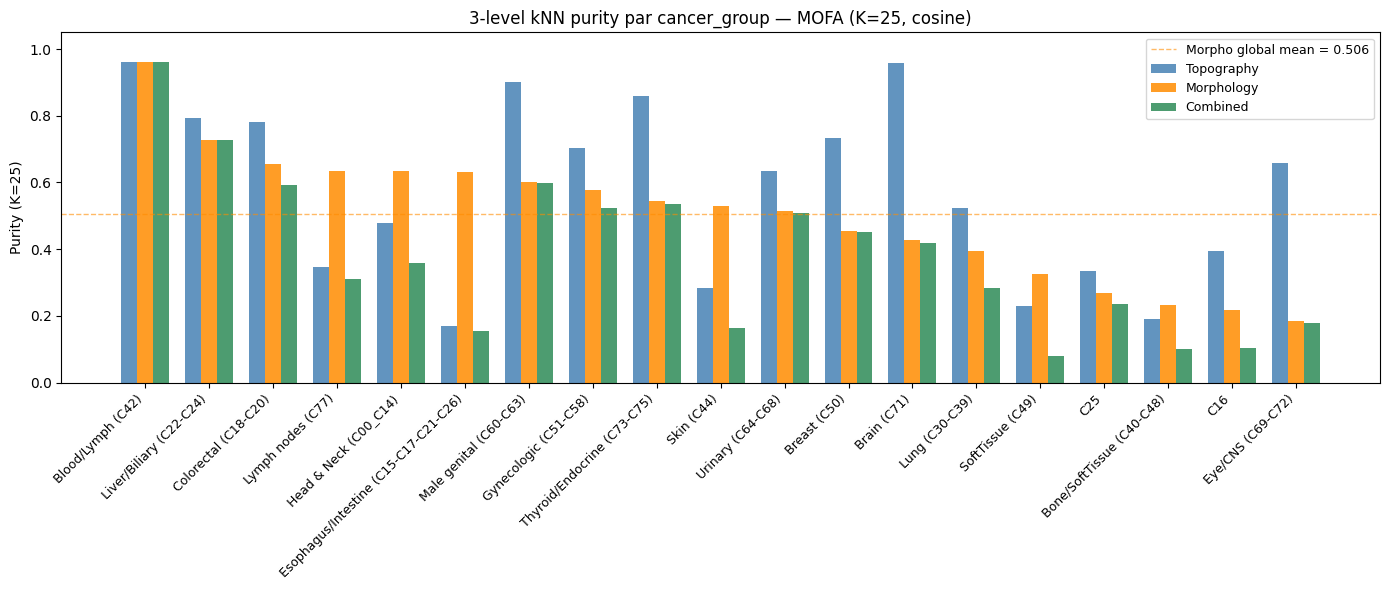

In [38]:
#Visualization
groups_ok = purity_by_group[purity_by_group["n_samples"] >= 20].copy()

x     = np.arange(len(groups_ok))
width = 0.25  

fig, ax = plt.subplots(figsize=(14, 6))

bars1 = ax.bar(x - width,     groups_ok["purity_topo"],
               width, label="Topography",  color="steelblue",  alpha=0.85)
bars2 = ax.bar(x,             groups_ok["purity_morpho"],
               width, label="Morphology",  color="darkorange", alpha=0.85)
bars3 = ax.bar(x + width,     groups_ok["purity_combined"],
               width, label="Combined",    color="seagreen",   alpha=0.85)


ax.axhline(purity_df["purity_morpho"].mean(), color="darkorange",
           linestyle="--", linewidth=1, alpha=0.6,
           label=f"Morpho global mean = {purity_df['purity_morpho'].mean():.3f}")

ax.set_xticks(x)
ax.set_xticklabels(groups_ok["cancer_group"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Purity (K=25)")
ax.set_ylim(0, 1.05)
ax.set_title(f"3-level kNN purity par cancer_group — MOFA (K=25, {BEST_METRIC})")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

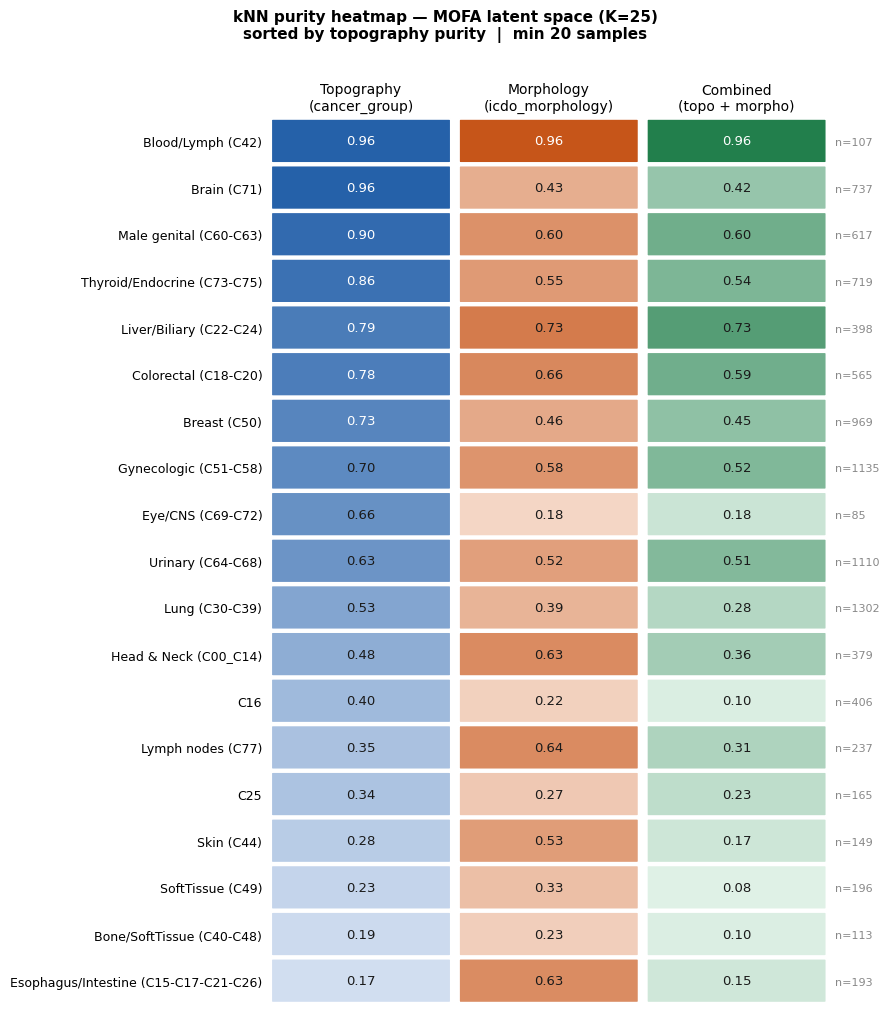

Heatmap plotted for 19 cancer groups (>=20 samples).


In [39]:
#Heatmap on the 3 levels of kNN purity by cancer group
def plot_purity_heatmap(purity_by_group: pd.DataFrame,
                        min_samples: int = 20,
                        figsize: tuple = (9, 10)) -> None:
    df = (
        purity_by_group[purity_by_group["n_samples"] >= min_samples]
        .sort_values("purity_topo", ascending=False)
        .reset_index(drop=True)
    )

    metrics    = ["purity_topo", "purity_morpho", "purity_combined"]
    labels     = ["Topography\n(cancer_group)", "Morphology\n(icdo_morphology)", "Combined\n(topo + morpho)"]
    col_colors = ["#4A90D9", "#E07B39", "#3BAA72"]

    cmaps = [
        mcolors.LinearSegmentedColormap.from_list("topo",  ["#F5F8FF", "#1D5BA6"]),
        mcolors.LinearSegmentedColormap.from_list("morpho",["#FFF5EE", "#C44E10"]),
        mcolors.LinearSegmentedColormap.from_list("comb",  ["#F0FBF4", "#1A7A45"]),
    ]

    data   = df[metrics].to_numpy()
    groups = df["cancer_group"].tolist()
    n_rows = len(groups)
    n_cols = len(metrics)

    cell_w = 2.2   # largeur d'une cellule en unités data
    cell_h = 0.8   # hauteur d'une cellule en unités data

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(-cell_w * 0.5, n_cols * cell_w - cell_w * 0.5)
    ax.set_ylim(-cell_h * 0.5, n_rows * cell_h - cell_h * 0.5)
    ax.invert_yaxis()

    norm = mcolors.Normalize(vmin=0, vmax=1)

    for col_idx, cmap in enumerate(cmaps):
        x_center = col_idx * cell_w
        for row_idx in range(n_rows):
            val  = data[row_idx, col_idx]
            rgba = cmap(norm(val))

            rect = FancyBboxPatch(
                (x_center - cell_w * 0.47, row_idx * cell_h - cell_h * 0.45),
                cell_w * 0.94, cell_h * 0.90,
                boxstyle="round,pad=0.02",
                facecolor=rgba, edgecolor="white", linewidth=1.5,
                transform=ax.transData, zorder=2
            )
            ax.add_patch(rect)

            lum = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
            txt_color = "white" if lum < 0.5 else "#1A1A1A"
            ax.text(x_center, row_idx * cell_h, f"{val:.2f}",
                    ha="center", va="center",
                    fontsize=9.5, fontweight="500", color=txt_color, zorder=3)

    # axes X
    ax.set_xticks([i * cell_w for i in range(n_cols)])
    ax.set_xticklabels(labels, fontsize=10, fontweight="500")
    for tick, color in zip(ax.get_xticklabels(), col_colors):
        tick.set_color(color)
    ax.xaxis.set_tick_params(length=0)
    ax.xaxis.set_label_position("top")
    ax.xaxis.tick_top()

    # axes Y
    ax.set_yticks([i * cell_h for i in range(n_rows)])
    ax.set_yticklabels(groups, fontsize=9)
    ax.yaxis.set_tick_params(length=0)

    # n_samples
    ax2 = ax.twinx()
    ax2.set_ylim(ax.get_ylim())
    ax2.set_yticks([i * cell_h for i in range(n_rows)])
    ax2.set_yticklabels(
        [f"n={int(df.loc[i, 'n_samples'])}" for i in range(n_rows)],
        fontsize=8, color="#888888"
    )
    ax2.yaxis.set_tick_params(length=0)
    ax2.spines[:].set_visible(False)

    ax.spines[:].set_visible(False)
    ax.set_facecolor("white")

    plt.suptitle(
        f"kNN purity heatmap — MOFA latent space (K=25)\n"
        f"sorted by topography purity  |  min {min_samples} samples",
        fontsize=11, fontweight="600", y=1.01
    )
    plt.tight_layout()
    plt.show()
    print(f"Heatmap plotted for {len(df)} cancer groups (>={min_samples} samples).")


# Appel
plot_purity_heatmap(purity_by_group, min_samples=20)

/var/folders/35/df9f7vc96sv9r7fc27r5csp40000gn/T/ipykernel_91133/3125905470.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette    = cm.get_cmap("tab20", len(all_labels))


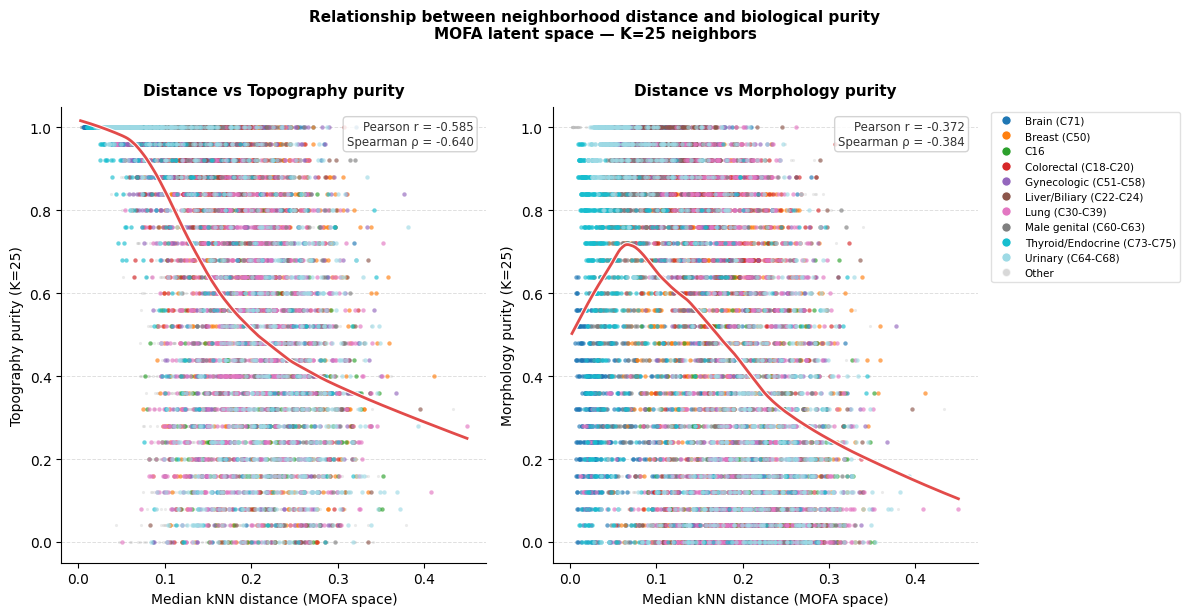

Scatter plotted on 9,582 samples (19 groups >= 30 samples).


In [40]:
#Scatter kNN median distance vs purete 
def plot_distance_vs_purity(purity_df: pd.DataFrame,
                             min_group_size: int = 30,
                             figsize: tuple = (12, 6)) -> None:

    df = purity_df.copy().reset_index(drop=True)  

    # Keep groups which are big enough 
    counts = df["cancer_group"].value_counts()
    valid  = counts[counts >= min_group_size].index
    df     = df[df["cancer_group"].isin(valid)].copy().reset_index(drop=True)

    # Top 10 groups, reste = Other
    top10      = df["cancer_group"].value_counts().head(10).index
    df["label"] = df["cancer_group"].where(df["cancer_group"].isin(top10), "Other")

    # Palette
    import matplotlib.cm as cm
    all_labels = sorted(df["label"].unique())
    palette    = cm.get_cmap("tab20", len(all_labels))
    color_map  = {lab: palette(i) for i, lab in enumerate(all_labels)}
    if "Other" in color_map:
        color_map["Other"] = (0.75, 0.75, 0.75, 0.4)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    for ax_idx, (y_col, y_label, title) in enumerate([
        ("purity_topo",   "Topography purity (K=25)", "Distance vs Topography purity"),
        ("purity_morpho", "Morphology purity (K=25)",  "Distance vs Morphology purity"),
    ]):
        ax = axes[ax_idx]

        # Other in background
        other = df[df["label"] == "Other"]
        if len(other):
            ax.scatter(other["dist_median"], other[y_col],
                       c=[color_map["Other"]], s=5, alpha=0.3,
                       linewidths=0, zorder=1)

        # Colored group 
        for lab in all_labels:
            if lab == "Other":
                continue
            sub = df[df["label"] == lab]
            ax.scatter(sub["dist_median"], sub[y_col],
                       c=[color_map[lab]], s=10, alpha=0.65,
                       linewidths=0, label=lab, zorder=2)

    
        try:
            from statsmodels.nonparametric.smoothers_lowess import lowess
            valid_mask = df[y_col].notna() & df["dist_median"].notna()
            df_v = df[valid_mask].copy()
            order = df_v["dist_median"].argsort().values   # positions entières
            x_s   = df_v["dist_median"].iloc[order].values  
            y_s   = df_v[y_col].iloc[order].values
            sm    = lowess(y_s, x_s, frac=0.3, return_sorted=True)
            ax.plot(sm[:, 0], sm[:, 1],
                    color="#E24B4A", linewidth=2, zorder=5,
                    label="Lowess trend",
                    path_effects=[pe.Stroke(linewidth=3.5, foreground="white"),
                                  pe.Normal()])
        except ImportError:
            pass

        # Correlations
        vm = df[y_col].notna() & df["dist_median"].notna()
        r_p, _ = pearsonr(df.loc[vm, "dist_median"], df.loc[vm, y_col])
        r_s, _ = spearmanr(df.loc[vm, "dist_median"], df.loc[vm, y_col])
        ax.text(0.97, 0.97,
                f"Pearson r = {r_p:.3f}\nSpearman ρ = {r_s:.3f}",
                transform=ax.transAxes, ha="right", va="top",
                fontsize=8.5, color="#333333",
                bbox=dict(facecolor="white", alpha=0.85,
                          edgecolor="#CCCCCC", boxstyle="round,pad=0.3"))

        ax.set_xlabel("Median kNN distance (MOFA space)", fontsize=10)
        ax.set_ylabel(y_label, fontsize=10)
        ax.set_title(title, fontsize=11, fontweight="600", pad=8)
        ax.set_ylim(-0.05, 1.05)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis="y", linestyle="--", alpha=0.4, linewidth=0.7)

    # Légende commune
    handles = [
        Line2D([0], [0], marker="o", color="w",
               markerfacecolor=color_map[lab], markersize=7, label=lab)
        for lab in all_labels if lab != "Other"
    ]
    handles.append(
        Line2D([0], [0], marker="o", color="w",
               markerfacecolor=(0.75, 0.75, 0.75, 0.6),
               markersize=6, label="Other")
    )
    axes[1].legend(handles=handles, bbox_to_anchor=(1.02, 1),
                   loc="upper left", fontsize=7.5,
                   framealpha=0.9, edgecolor="#DDDDDD")

    plt.suptitle(
        "Relationship between neighborhood distance and biological purity\n"
        "MOFA latent space — K=25 neighbors",
        fontsize=11, fontweight="600", y=1.02
    )
    plt.tight_layout()
    plt.show()
    print(f"Scatter plotted on {len(df):,} samples "
          f"({df['cancer_group'].nunique()} groups >= {min_group_size} samples).")


# Appel
plot_distance_vs_purity(purity_df, min_group_size=30)

### kNN per cancer_group

In [41]:
def build_knn_from_PCs(ids, X, K, metric="euclidean"):
    n = X.shape[0]
    nn = NearestNeighbors(n_neighbors=K + 1, metric=metric, algorithm="auto")
    nn.fit(X)
    dists, idx = nn.kneighbors(X, return_distance=True)
    idx   = idx[:, 1:]
    dists = dists[:, 1:]
    neigh_ids   = ids[idx]
    neigh_dists = dists.astype(np.float32)
    return neigh_ids, neigh_dists

def mean_jaccard_overlap(neigh_a, neigh_b):
    n  = neigh_a.shape[0]
    js = np.empty(n, dtype=float)
    for i in range(n):
        A = set(str(x) for x in neigh_a[i] if x is not None)
        B = set(str(x) for x in neigh_b[i] if x is not None)
        js[i] = len(A & B) / max(1, len(A | B))
    return float(np.mean(js))

def knn_purity_from_neighbors(query_ids, neigh_ids, meta_df,
                               label_col=LABEL_COL, id_col=ID_COL):
    if label_col not in meta_df.columns:
        return float("nan")
    lab = dict(zip(meta_df[id_col].astype(str), meta_df[label_col].astype(str)))
    pur = []
    for i, qid in enumerate(query_ids.astype(str)):
        qlab = lab.get(qid)
        if qlab is None:
            continue
        nids = [str(x) for x in neigh_ids[i] if x is not None]
        if not nids:
            continue
        same = sum(1 for nid in nids if lab.get(nid) == qlab)
        pur.append(same / len(nids))
    return float(np.mean(pur)) if pur else float("nan")

def pick_best_setting(df_group):

    MAX_PURITY_DROP = 0.01
    base = df_group[
        (df_group["metric"] == "euclidean") &
        (df_group["n_factors"] == 20)
    ]
    pur_base = float(base["morph_purity"].iloc[0]) if len(base) else np.nan

    cand = df_group[
        np.isfinite(df_group["delta_purity"]) &
        (df_group["delta_purity"] >= -MAX_PURITY_DROP)
    ].copy()

    if len(cand) == 0:
        # fallback baseline
        row = df_group[
            (df_group["metric"] == "euclidean") &
            (df_group["n_factors"] == 20)
        ].iloc[0].copy()
        row["accepted"] = False
        return row

    best_pur = cand["morph_purity"].max()
    top = cand[cand["morph_purity"] >= best_pur - 1e-6]
    top = top.sort_values(["morph_purity", "jaccard_vs_baseline"],
                          ascending=[False, False])
    row = top.iloc[0].copy()
    row["accepted"] = True
    return row

In [42]:
SWEEP_METRICS  = ["euclidean", "cosine"]
SWEEP_N_FACTORS = [10, 20]
K_SWEEP = 50
MIN_SAMPLES_FOR_KNN = K + 10

group_counts  = meta_aligned[LABEL_COL].value_counts()
valid_groups  = group_counts[group_counts >= MIN_SAMPLES_FOR_KNN].index.tolist()
skipped       = group_counts[group_counts < MIN_SAMPLES_FOR_KNN].index.tolist()
print(f"Valid groups : {len(valid_groups)} | Skipped : {skipped}")

rows_sweep = []

for cancer_group in sorted(valid_groups):
    mask    = meta_aligned[LABEL_COL] == cancer_group
    ids_grp = meta_aligned.loc[mask, ID_COL].astype(str).to_numpy()
    X_full  = Z_mofa_df.loc[ids_grp, factor_cols].to_numpy(dtype=np.float32)
    n_grp   = len(ids_grp)

    # baseline euclidean 20 facteurs
    neigh_base, _ = build_knn_from_PCs(ids_grp, X_full, K=K_SWEEP, metric="euclidean")
    pur_base = knn_purity_from_neighbors(ids_grp, neigh_base, meta_aligned)

    for metric in SWEEP_METRICS:
        for n_fac in SWEEP_N_FACTORS:
            X = X_full[:, :n_fac]
            neigh, dist = build_knn_from_PCs(ids_grp, X, K=K_SWEEP, metric=metric)
            pur = knn_purity_from_neighbors(ids_grp, neigh, meta_aligned)
            jac = mean_jaccard_overlap(neigh, neigh_base)

            rows_sweep.append({
                "cancer_group":          cancer_group,
                "n_eval":                int(n_grp),
                "metric":                metric,
                "n_factors":             int(n_fac),
                "K":                     int(K_SWEEP),
                "jaccard_vs_baseline":   float(jac),
                "morph_purity_baseline": float(pur_base) if np.isfinite(pur_base) else np.nan,
                "morph_purity":          float(pur)      if np.isfinite(pur)      else np.nan,
                "delta_purity":          float(pur - pur_base)
                                         if np.isfinite(pur) and np.isfinite(pur_base)
                                         else np.nan,
            })

stability_mofa_df = pd.DataFrame(rows_sweep)
print(stability_mofa_df)

Valid groups : 19 | Skipped : ['C76', 'C80', 'C47']
                   cancer_group  n_eval     metric  n_factors   K  \
0             Blood/Lymph (C42)     107  euclidean         10  50   
1             Blood/Lymph (C42)     107  euclidean         20  50   
2             Blood/Lymph (C42)     107     cosine         10  50   
3             Blood/Lymph (C42)     107     cosine         20  50   
4     Bone/SoftTissue (C40-C48)     113  euclidean         10  50   
..                          ...     ...        ...        ...  ..   
71  Thyroid/Endocrine (C73-C75)     719     cosine         20  50   
72            Urinary (C64-C68)    1110  euclidean         10  50   
73            Urinary (C64-C68)    1110  euclidean         20  50   
74            Urinary (C64-C68)    1110     cosine         10  50   
75            Urinary (C64-C68)    1110     cosine         20  50   

    jaccard_vs_baseline  morph_purity_baseline  morph_purity  delta_purity  
0              0.924922                   

In [43]:
best_mofa = pd.DataFrame([
    pick_best_setting(g)
    for _, g in stability_mofa_df.groupby("cancer_group")
]).reset_index(drop=True)

print(best_mofa[["cancer_group", "metric", "n_factors", "morph_purity", "accepted"]])


                             cancer_group     metric  n_factors  morph_purity  \
0                       Blood/Lymph (C42)  euclidean         20           1.0   
1               Bone/SoftTissue (C40-C48)  euclidean         20           1.0   
2                             Brain (C71)  euclidean         20           1.0   
3                            Breast (C50)  euclidean         20           1.0   
4                                     C16  euclidean         20           1.0   
5                                     C25  euclidean         20           1.0   
6                    Colorectal (C18-C20)  euclidean         20           1.0   
7   Esophagus/Intestine (C15-C17-C21-C26)  euclidean         20           1.0   
8                       Eye/CNS (C69-C72)  euclidean         20           1.0   
9                   Gynecologic (C51-C58)  euclidean         20           1.0   
10                  Head & Neck (C00_C14)  euclidean         20           1.0   
11                Liver/Bili

In [44]:
KNN_BY_GROUP_DIR = OUT_DIR / "knn_by_cancer_group"
OUT_PERGROUP_BEST = KNN_BY_GROUP_DIR / "pergroup_best"
OUT_BASELINE      = KNN_BY_GROUP_DIR / "baseline_euc20"
KNN_BY_GROUP_DIR.mkdir(parents=True, exist_ok=True)
OUT_PERGROUP_BEST.mkdir(parents=True, exist_ok=True)
OUT_BASELINE.mkdir(parents=True, exist_ok=True)

best_map = best_mofa.set_index("cancer_group")[
    ["metric", "n_factors", "accepted"]
].to_dict(orient="index")

manifest_A = []
manifest_B = []

for cancer_group in sorted(valid_groups):
    group_tag = (cancer_group
                 .replace(" ", "_").replace("(", "").replace(")", "")
                 .replace("/", "_"))

    mask    = meta_aligned[LABEL_COL] == cancer_group
    ids_grp = meta_aligned.loc[mask, ID_COL].astype(str).to_numpy()
    X_full  = Z_mofa_df.loc[ids_grp, factor_cols].to_numpy(dtype=np.float32)
    n_grp   = len(ids_grp)
    K_grp   = min(K_SWEEP, n_grp - 1)

    #  Graph A : best par groupe 
    best_metric   = str(best_map[cancer_group]["metric"])
    best_n_factors = int(best_map[cancer_group]["n_factors"])
    X_best = X_full[:, :best_n_factors]

    neigh_A, dist_A = build_knn_from_PCs(ids_grp, X_best, K=K_grp, metric=best_metric)

    out_idx_A  = OUT_PERGROUP_BEST / f"{group_tag}_knn_idx_k{K_grp}_factors{best_n_factors}_{best_metric}.parquet"
    out_dist_A = OUT_PERGROUP_BEST / f"{group_tag}_knn_dist_k{K_grp}_factors{best_n_factors}_{best_metric}.parquet"

    pd.DataFrame(neigh_A, columns=[f"nn{i+1}" for i in range(K_grp)]).assign(
        **{ID_COL: ids_grp}
    )[[ID_COL] + [f"nn{i+1}" for i in range(K_grp)]].to_parquet(out_idx_A, index=False)

    pd.DataFrame(dist_A, columns=[f"d{i+1}" for i in range(K_grp)]).assign(
        **{ID_COL: ids_grp}
    )[[ID_COL] + [f"d{i+1}" for i in range(K_grp)]].to_parquet(out_dist_A, index=False)

    manifest_A.append({
        "cancer_group":  cancer_group,
        "n_samples":     int(n_grp),
        "K":             int(K_grp),
        "metric":        best_metric,
        "n_factors_used": best_n_factors,
        "accepted":      bool(best_map[cancer_group]["accepted"]),
        "knn_idx_file":  out_idx_A.name,
        "knn_dist_file": out_dist_A.name,
    })
    print(f"[A saved] {cancer_group} : K={K_grp} metric={best_metric} n_factors={best_n_factors}")

    #  Graph B : baseline euc20 
    neigh_B, dist_B = build_knn_from_PCs(ids_grp, X_full, K=K_grp, metric="euclidean")

    out_idx_B  = OUT_BASELINE / f"{group_tag}_knn_idx_k{K_grp}_factors20_euclidean.parquet"
    out_dist_B = OUT_BASELINE / f"{group_tag}_knn_dist_k{K_grp}_factors20_euclidean.parquet"

    pd.DataFrame(neigh_B, columns=[f"nn{i+1}" for i in range(K_grp)]).assign(
        **{ID_COL: ids_grp}
    )[[ID_COL] + [f"nn{i+1}" for i in range(K_grp)]].to_parquet(out_idx_B, index=False)

    pd.DataFrame(dist_B, columns=[f"d{i+1}" for i in range(K_grp)]).assign(
        **{ID_COL: ids_grp}
    )[[ID_COL] + [f"d{i+1}" for i in range(K_grp)]].to_parquet(out_dist_B, index=False)

    manifest_B.append({
        "cancer_group":   cancer_group,
        "n_samples":      int(n_grp),
        "K":              int(K_grp),
        "metric":         "euclidean",
        "n_factors_used": 20,
        "knn_idx_file":   out_idx_B.name,
        "knn_dist_file":  out_dist_B.name,
    })

# Manifests
pd.DataFrame(manifest_A).sort_values("cancer_group").to_csv(
    OUT_PERGROUP_BEST / "knn_manifest.tsv", sep="\t", index=False)
pd.DataFrame(manifest_B).sort_values("cancer_group").to_csv(
    OUT_BASELINE / "knn_manifest.tsv", sep="\t", index=False)

print(f"\n[saved] Graph A → {OUT_PERGROUP_BEST}")
print(f"[saved] Graph B → {OUT_BASELINE}")

[A saved] Blood/Lymph (C42) : K=50 metric=euclidean n_factors=20
[A saved] Bone/SoftTissue (C40-C48) : K=50 metric=euclidean n_factors=20
[A saved] Brain (C71) : K=50 metric=euclidean n_factors=20
[A saved] Breast (C50) : K=50 metric=euclidean n_factors=20
[A saved] C16 : K=50 metric=euclidean n_factors=20
[A saved] C25 : K=50 metric=euclidean n_factors=20
[A saved] Colorectal (C18-C20) : K=50 metric=euclidean n_factors=20
[A saved] Esophagus/Intestine (C15-C17-C21-C26) : K=50 metric=euclidean n_factors=20
[A saved] Eye/CNS (C69-C72) : K=50 metric=euclidean n_factors=20
[A saved] Gynecologic (C51-C58) : K=50 metric=euclidean n_factors=20
[A saved] Head & Neck (C00_C14) : K=50 metric=euclidean n_factors=20
[A saved] Liver/Biliary (C22-C24) : K=50 metric=euclidean n_factors=20
[A saved] Lung (C30-C39) : K=50 metric=euclidean n_factors=20
[A saved] Lymph nodes (C77) : K=50 metric=euclidean n_factors=20
[A saved] Male genital (C60-C63) : K=50 metric=euclidean n_factors=20
[A saved] Skin (C

In [45]:
# ── QC par groupe — Graph A ────────────────────────────────────

def check_group_knn_integrity(idx_path, dist_path, ids_grp, group_tag, K_grp):
    
    issues = []

    ids_df  = pd.read_parquet(idx_path)
    dist_df = pd.read_parquet(dist_path)

    nn_cols   = [c for c in ids_df.columns  if c != ID_COL]
    dist_cols = [c for c in dist_df.columns if c != ID_COL]

    knn_ids_grp   = ids_df[nn_cols].to_numpy(dtype=object)
    knn_dists_grp = dist_df[dist_cols].to_numpy(dtype=np.float32)

    ids_set = set(ids_grp.astype(str))
    n = len(ids_grp)

    # 1. Self-neighbor
    ids_col = ids_grp.reshape(-1, 1)
    n_self  = int(np.any(knn_ids_grp == ids_col, axis=1).sum())
    if n_self > 0:
        issues.append(f"self-neighbor: {n_self} samples")

    # 2. Monotonic distances
    diffs = np.diff(knn_dists_grp, axis=1)
    n_non_mono = int((diffs < -1e-5).any(axis=1).sum())
    if n_non_mono > 0:
        issues.append(f"non-monotone distances: {n_non_mono} samples")

    # 3. Unknown neighbor IDs
    all_neigh = knn_ids_grp.ravel().astype(str)
    n_unknown = int(sum(1 for nid in all_neigh if nid not in ids_set))
    if n_unknown > 0:
        issues.append(f"unknown neighbor IDs: {n_unknown}")

    # 4. Shape cohérence
    if knn_ids_grp.shape[0] != n:
        issues.append(f"row mismatch: {knn_ids_grp.shape[0]} vs {n}")

    return {
        "cancer_group":    group_tag,
        "n_samples":       n,
        "K_saved":         knn_ids_grp.shape[1],
        "n_self":          n_self,
        "n_non_monotone":  n_non_mono,
        "n_unknown_ids":   n_unknown,
        "ok":              len(issues) == 0,
        "issues":          "; ".join(issues) if issues else "",
    }

qc_A_rows = []
for row in manifest_A:
    cancer_group = row["cancer_group"]
    group_tag    = (cancer_group
                    .replace(" ", "_").replace("(", "").replace(")", "")
                    .replace("/", "_"))
    
    mask    = meta_aligned[LABEL_COL] == cancer_group
    ids_grp = meta_aligned.loc[mask, ID_COL].astype(str).to_numpy()

    idx_path  = OUT_PERGROUP_BEST / row["knn_idx_file"]
    dist_path = OUT_PERGROUP_BEST / row["knn_dist_file"]

    qc_A_rows.append(check_group_knn_integrity(
        idx_path, dist_path, ids_grp, cancer_group, row["K"]
    ))

qc_A_df = pd.DataFrame(qc_A_rows).sort_values(["ok", "n_unknown_ids"], ascending=[True, False])

print("QC Graph A (per-group best) :")
print(qc_A_df[["cancer_group", "n_samples", "K_saved",
               "n_self", "n_non_monotone", "n_unknown_ids",
               "ok", "issues"]].to_string(index=False))

n_ok  = int(qc_A_df["ok"].sum())
n_bad = int((~qc_A_df["ok"]).sum())
print(f"\n{n_ok}/{len(qc_A_df)} groups OK")
if n_bad > 0:
    print(f"WARNING : {n_bad} groups with issues")

QC Graph A (per-group best) :
                         cancer_group  n_samples  K_saved  n_self  n_non_monotone  n_unknown_ids   ok issues
                    Blood/Lymph (C42)        107       50       0               0              0 True       
            Bone/SoftTissue (C40-C48)        113       50       0               0              0 True       
                          Brain (C71)        737       50       0               0              0 True       
                         Breast (C50)        969       50       0               0              0 True       
                                  C16        406       50       0               0              0 True       
                                  C25        165       50       0               0              0 True       
                 Colorectal (C18-C20)        565       50       0               0              0 True       
Esophagus/Intestine (C15-C17-C21-C26)        193       50       0               0              0 T

In [46]:
# Save
out_purity_sample = OUT_DIR / "mofa_purity_per_sample.tsv"
out_purity_group  = OUT_DIR / "mofa_purity_per_group.tsv"

purity_df.to_csv(out_purity_sample,  sep="\t", index=False)
purity_by_group.to_csv(out_purity_group, sep="\t", index=False)

print(f"[saved] {out_purity_sample.name}")
print(f"[saved] {out_purity_group.name}")

[saved] mofa_purity_per_sample.tsv
[saved] mofa_purity_per_group.tsv
